# 01 - 探索性資料分析 (EDA) & 資料清理

富邦金控 MA 甄選 — 題目二：客戶意圖分類

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import sys, os

# 加入專案根目錄
sys.path.insert(0, os.path.abspath('..'))
from src.data_preprocess import TextPreprocessor, load_dataset

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. 載入資料

In [2]:
raw_dir = '../data/raw'

# 自動尋找 train / eval 檔案（支援中文檔名）
train_path, eval_path = None, None
for f in os.listdir(raw_dir):
    if 'train' in f and f.endswith('.json'):
        train_path = os.path.join(raw_dir, f)
    elif 'eval' in f and f.endswith('.json'):
        eval_path = os.path.join(raw_dir, f)

print(f"Train file: {train_path}")
print(f"Eval file:  {eval_path}")

train_texts, train_labels, train_ids = load_dataset(train_path)
eval_texts, eval_labels, eval_ids = load_dataset(eval_path)

print(f"\n訓練集: {len(train_texts)} 筆")
print(f"評估集: {len(eval_texts)} 筆")
print(f"意圖類別數: {len(set(train_labels))}")

Train file: ../data/raw\題目二_附件_意圖偵測資料集_train.json
Eval file:  ../data/raw\題目二_附件_意圖偵測資料集_eval.json

訓練集: 15000 筆
評估集: 3000 筆
意圖類別數: 150


## 2. 基本統計

In [3]:
# 意圖分佈
counter = Counter(train_labels)
print(f"每類樣本數是否相同: {len(set(counter.values())) == 1}")
print(f"每類樣本數: {list(counter.values())[0]}")

# 文本長度分佈
lengths = [len(t.split()) for t in train_texts]
print(f"\n文本長度統計 (詞數):")
print(f"  平均: {np.mean(lengths):.1f}")
print(f"  中位數: {np.median(lengths):.0f}")
print(f"  最短: {min(lengths)}")
print(f"  最長: {max(lengths)}")

每類樣本數是否相同: True
每類樣本數: 100

文本長度統計 (詞數):
  平均: 8.3
  中位數: 8
  最短: 1
  最長: 28


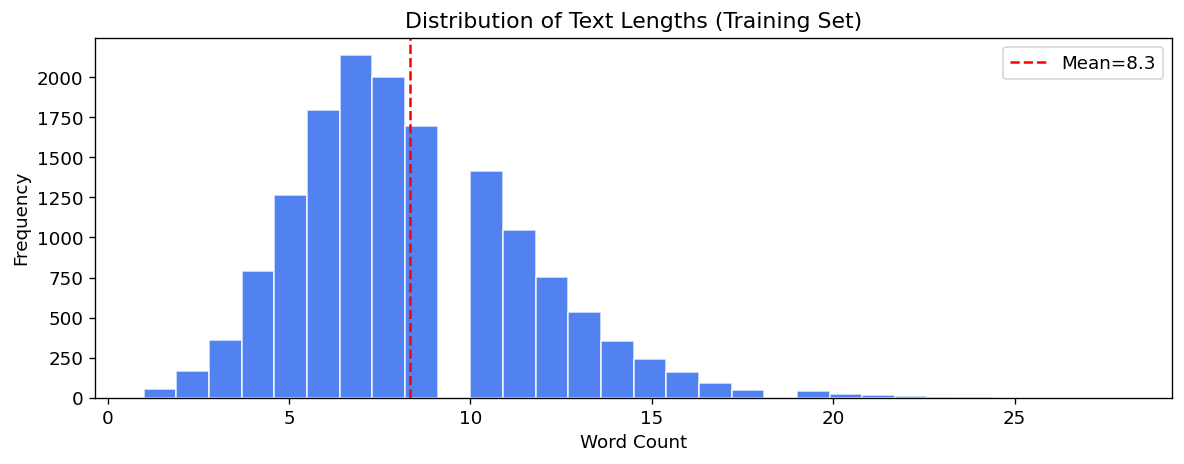

In [4]:
# 文本長度分佈圖
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=30, color='#2563EB', alpha=0.8, edgecolor='white')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Text Lengths (Training Set)')
ax.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean={np.mean(lengths):.1f}')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 意圖領域分佈

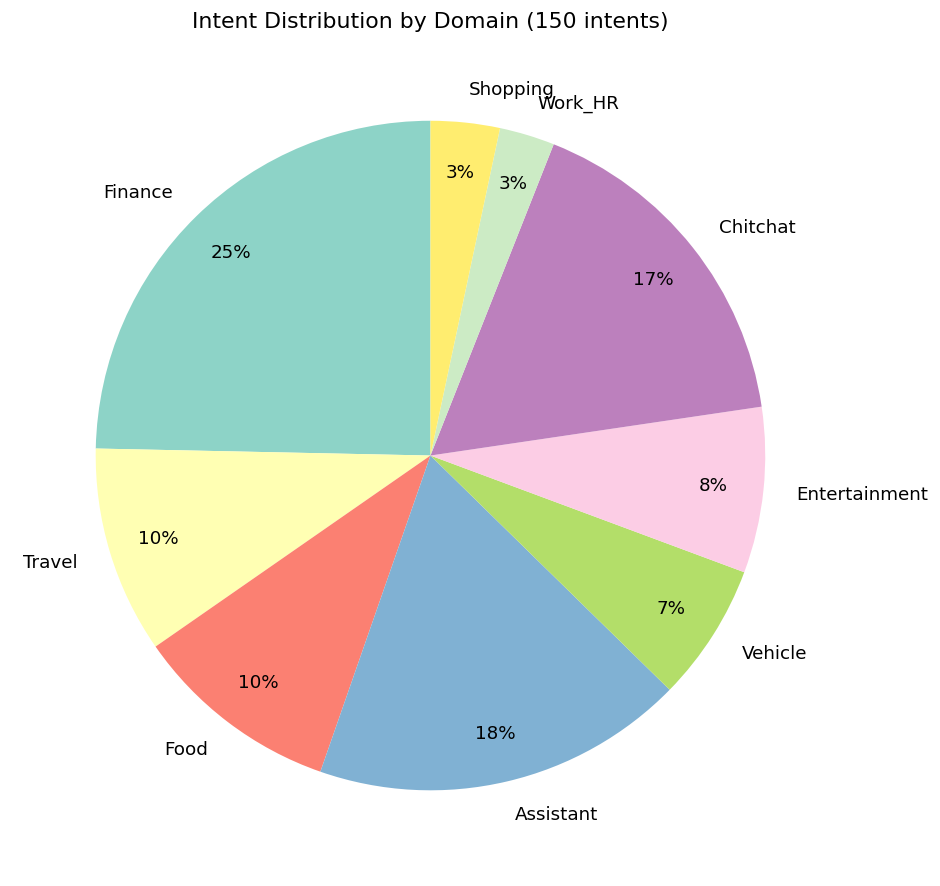

  Finance        : 37 intents
  Assistant      : 27 intents
  Chitchat       : 25 intents
  Travel         : 15 intents
  Food           : 15 intents
  Entertainment  : 12 intents
  Vehicle        : 10 intents
  Shopping       : 5 intents
  Work_HR        : 4 intents


In [5]:
from src.evaluator import INTENT_DOMAINS

domain_counts = {}
for domain, intents in INTENT_DOMAINS.items():
    domain_counts[domain] = len(intents)

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(domain_counts)))
ax.pie(domain_counts.values(), labels=domain_counts.keys(), autopct='%1.0f%%',
       colors=colors, pctdistance=0.85, startangle=90)
ax.set_title(f'Intent Distribution by Domain ({sum(domain_counts.values())} intents)')
plt.tight_layout()
plt.show()

for d, c in sorted(domain_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {d:15s}: {c} intents")

## 4. 前處理範例展示

In [6]:
preprocessor = TextPreprocessor()

print("斷詞斷句範例：\n")
for i in [0, 1, 2, 50, 100]:
    print(f"--- 第 {i} 筆 | 意圖: {train_labels[i]} ---")
    preprocessor.transform(train_texts[i], verbose=True)
    print()

斷詞斷句範例：

--- 第 0 筆 | 意圖: book_flight ---
  [原始] i need you to book me a flight from ft lauderdale to houston on southwest
  [斷詞] ['i', 'need', 'you', 'to', 'book', 'me', 'a', 'flight', 'from', 'ft', 'lauderdale', 'to', 'houston', 'on', 'southwest']
  [去停用詞] ['need', 'book', 'flight', 'ft', 'lauderdale', 'houston', 'southwest']
  [結果] need book flight ft lauderdale houston southwest

--- 第 1 筆 | 意圖: schedule_maintenance ---
  [原始] my check engine light is on and i need to take a look at it
  [斷詞] ['my', 'check', 'engine', 'light', 'is', 'on', 'and', 'i', 'need', 'to', 'take', 'a', 'look', 'at', 'it']
  [去停用詞] ['check', 'engine', 'light', 'need', 'take', 'look']
  [結果] check engine light need take look

--- 第 2 筆 | 意圖: reminder ---
  [原始] is the company party on my list of reminders
  [斷詞] ['is', 'the', 'company', 'party', 'on', 'my', 'list', 'of', 'reminders']
  [去停用詞] ['company', 'party', 'list', 'reminders']
  [結果] company party list reminders

--- 第 50 筆 | 意圖: shopping_list ---
  [原始

In [7]:
# 批次前處理
train_clean = preprocessor.transform_batch(train_texts)
eval_clean = preprocessor.transform_batch(eval_texts)

avg_before = np.mean([len(t.split()) for t in train_texts])
avg_after = np.mean([len(t.split()) for t in train_clean])
print(f"前處理前平均詞數: {avg_before:.1f}")
print(f"前處理後平均詞數: {avg_after:.1f}")
print(f"平均移除: {avg_before - avg_after:.1f} 個詞")

前處理前平均詞數: 8.3
前處理後平均詞數: 4.7
平均移除: 3.6 個詞


## 5. 易混淆意圖對分析

In [8]:
confusing_pairs = [
    ('travel_alert', 'travel_notification'),
    ('todo_list', 'todo_list_update'),
    ('reminder', 'reminder_update'),
    ('calendar', 'calendar_update'),
    ('credit_limit', 'credit_limit_change'),
    ('bill_balance', 'bill_due'),
    ('pto_balance', 'pto_used'),
    ('account_blocked', 'freeze_account'),
    ('insurance', 'insurance_change'),
]

raw_data_map = {train_ids[i]: train_texts[i] for i in range(len(train_ids))}
intent_examples = {}
for i in range(len(train_texts)):
    if train_labels[i] not in intent_examples:
        intent_examples[train_labels[i]] = []
    if len(intent_examples[train_labels[i]]) < 2:
        intent_examples[train_labels[i]].append(train_texts[i])

print("易混淆意圖對：\n")
for a, b in confusing_pairs:
    print(f"  {a} vs {b}")
    for ex in intent_examples.get(a, [])[:1]:
        print(f"    {a}: \"{ex}\"")
    for ex in intent_examples.get(b, [])[:1]:
        print(f"    {b}: \"{ex}\"")
    print()

易混淆意圖對：

  travel_alert vs travel_notification
    travel_alert: "does japan have any travel alerts i should be aware of"
    travel_notification: "can you let my bank know i'll be in uruguay from january to august"

  todo_list vs todo_list_update
    todo_list: "do i have get an oil change on my todo list"
    todo_list_update: "i need to do cleaning so add it to my to do list"

  reminder vs reminder_update
    reminder: "is the company party on my list of reminders"
    reminder_update: "please remind me to do this later"

  calendar vs calendar_update
    calendar: "how is my calendar looking for may 6th"
    calendar_update: "make sure april 1 is clear on my calendar"

  credit_limit vs credit_limit_change
    credit_limit: "how much can i spend, at most, on my chase freedom"
    credit_limit_change: "i need to increase my credit limit"

  bill_balance vs bill_due
    bill_balance: "how much is my gas bill"
    bill_due: "what day is my car insurance due"

  pto_balance vs pto_us